In [ ]:
library(rtracklayer)
library(GenomicRanges)
library(annotatr)

dm_regions = read_regions(con = 'indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.bed', genome = 'hg38', format = 'bed')
annots = c('hg38_basicgenes', 'hg38_genes_intergenic',
    'hg38_genes_intronexonboundaries','hg38_cpgs'
    )
annotations = build_annotations(genome = 'hg38', annotations = annots)
# Intersect the regions we read in with the annotations
dm_annotated = annotate_regions(
    regions = dm_regions,
    annotations = annotations,
    ignore.strand = TRUE,
    quiet = FALSE)

granges_df <- as.data.frame(dm_annotated)
write.csv(granges_df, "indexing/SNP_annotatr_20240902.csv", row.names = FALSE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

'select()' returned 1:1 mapping between keys and columns

Building promoters...

Building 1to5kb upstream of TSS...

Building intergenic...

Building 5UTRs...

Building 3UTRs...

Building exons...

Building introns...

Building intron exon boundaries...

Building CpG islands...

Building CpG shores...

Building CpG shelves...

Building inter-CpG-islands...

Annotating...



In [ ]:
import pandas as pd
df_annot = pd.read_csv("indexing/SNP_annotatr_20240902.csv")
df_haploreg = pd.read_csv('indexing/SNP_haploreg_annotated_index_20240818_curated_annotated.csv',index_col=0 )
df_annot['annot.type'] = df_annot['annot.type'].str.replace('hg38_', '')
df_annot['snp'] = df_annot['seqnames'] +":"+ (df_annot['start']-1).astype(str) +"-"+ (df_annot['end']-1).astype(str)
# Group by 'snp' and accumulate unique 'annot.type' entries
df_annot['annot.symbol'] = df_annot['annot.symbol'].astype(str)
result = pd.DataFrame(df_annot.groupby('snp')['annot.type'].apply(lambda x: ', '.join(x.unique())))
result['annot.symbol'] = df_annot.groupby('snp')['annot.symbol'].apply(lambda x: ', '.join(x.unique()))
import pandas as pd
# Create dummy variables for each unique value in 'annot.type'
dummies = pd.get_dummies(df_annot['annot.type'])
# Concatenate the dummies with the 'snp' column of your DataFrame
df_annot = pd.concat([df_annot['snp'], dummies], axis=1)
# Group by 'snp' and sum the dummy variables to get binary presence/absence data
result = df_annot.groupby('snp').sum()
df_haploreg['coordinate'] = df_haploreg['chr']+":"+ df_haploreg['pos_hg38'].astype(int).astype(str) +"-"+ df_haploreg['pos_hg38'].astype(int).astype(str)
pd.merge(df_haploreg,result,left_on="coordinate",right_index=True).to_csv('indexing/SNP_haploregannotatr_annotated_index_20240902_curated_annotated.csv')

In [ ]:
import pandas as pd
df = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_20240904.csv',index_col=0)
df_annot = df[[ 'cpg_inter',
       'cpg_islands', 'cpg_shelves', 'cpg_shores', 'genes_1to5kb',
       'genes_3UTRs', 'genes_5UTRs', 'genes_exons', 'genes_intergenic',
       'genes_intronexonboundaries', 'genes_introns', 'genes_promoters']].applymap(lambda x: 1 if x != 0 else 0)
df_unique = df.drop_duplicates('RSID')
df_unique

/tmp/ipykernel_54201/2635111803.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  'genes_intronexonboundaries', 'genes_introns', 'genes_promoters']].applymap(lambda x: 1 if x != 0 else 0)


,Type,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,r2,D',is_query_snp,...,UCLA_IFNG,UCLA_NAIVE,vEndo.Kellis,WTC11resting,WTC11stimulated,IFNB4_vs_Naive_IHW,IFNG4_vs_Naive_IHW,LPSIFNG4_vs_Naive_IHW,GC_content,distance_to_tss
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,AD,cg03073402,Bertram,LIPE,cg03073402,19,42423524,NaN,NaN,NaN,...,0,0,0,2,1,0,0,1,68.281938,1547
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,AD,cg03169557,Bertram,SPG7,cg03169557,16,89532542,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,62.114537,-28082
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,AD,cg05030077,Bertram,MLST8,cg05030077,16,2205198,NaN,NaN,NaN,...,0,0,0,4,3,0,0,1,56.828194,-950
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,AD,cg05066959,Bertram,ANK1,cg05066959,8,41661790,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,60.792952,-799
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,AD,cg05228284,Bertram,DIRAS1,cg05228284,19,2720849,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,73.568282,523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,AD,rs9478143,Tanzi,MTHFD1L,rs9478143,6,150862035,1.0,1.0,1.0,...,0,0,0,1,0,0,0,0,46.255507,3644
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,AD,rs953471,Tanzi,NEK6,rs953471,9,124221903,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,48.458150,35703
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,AD,rs965034941,Tanzi,BTBD2,rs965034941,19,1999195,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,67.111111,4386
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,AD,rs983392,Pfenning,MS4A6A,rs983392,11,60156035,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,35.682819,4787


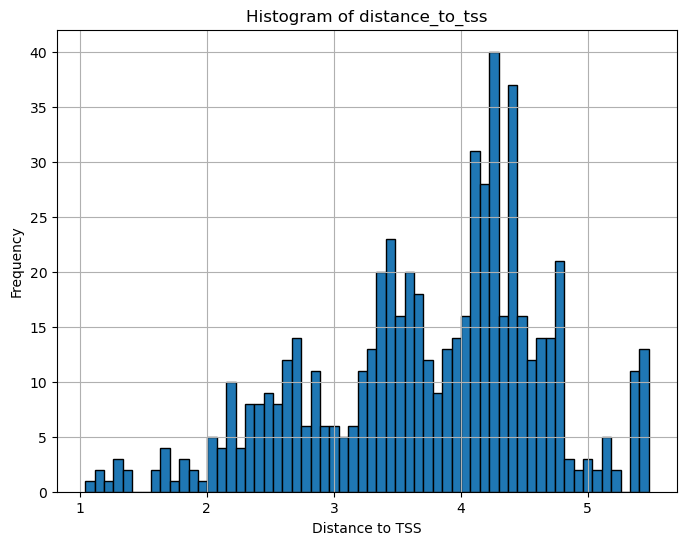

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Plotting the histogram
plt.figure(figsize=(8, 6))
plt.hist(np.log10(abs(df_unique['distance_to_tss'])), bins=60, edgecolor='black')
plt.title('Histogram of distance_to_tss')
plt.xlabel('Distance to TSS')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [7]:
df_annot['RSID'] = df['RSID']
df_annot_unique = df_annot.drop_duplicates('RSID').drop(['RSID'],axis=1)
category_counts = round(df_annot_unique.sum()/len(df_annot_unique),2)
print(category_counts)

cpg_inter                     0.69
cpg_islands                   0.13
cpg_shelves                   0.05
cpg_shores                    0.13
genes_1to5kb                  0.30
genes_3UTRs                   0.03
genes_5UTRs                   0.05
genes_exons                   0.16
genes_intergenic              0.27
genes_intronexonboundaries    0.11
genes_introns                 0.57
genes_promoters               0.24
dtype: float64


In [8]:
category_counts = category_counts.rename({
                        'genes_1to5kb': '1-5kb to TSS', 
                        'genes_3UTRs':'3\' UTR',
                        'genes_5UTRs':'5\' UTR',
                        'genes_exons':'Exon',
                        'genes_intergenic':"Intergenic",
                        'genes_intronexonboundaries':'Intron-exon Boundaries',
                        'genes_introns': 'Introns',
                        'genes_promoters': 'Promoters'
                        })

/tmp/ipykernel_54201/3439936472.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(types))


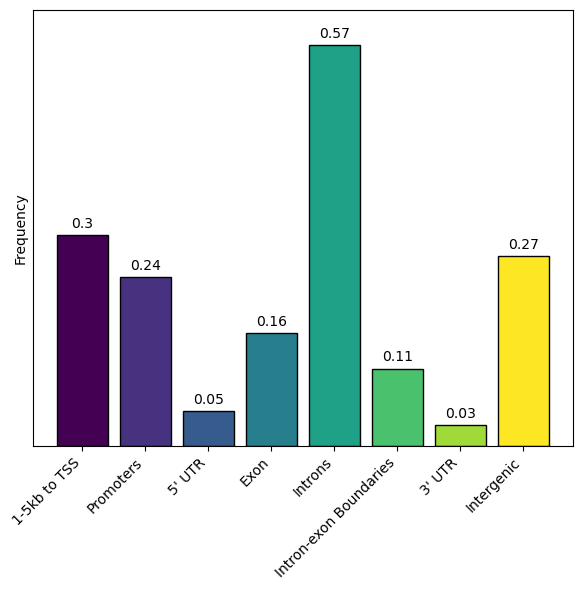

In [12]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming category_counts_genes is a DataFrame with relevant data
category_counts_genes = category_counts[['1-5kb to TSS','Promoters',
        '5\' UTR', 'Exon','Introns','Intron-exon Boundaries','3\' UTR', 'Intergenic']]
# Create the bar plot
fig, ax = plt.subplots(figsize=(6, 6))  # You can adjust figsize as needed
types = category_counts_genes.index
colors = plt.cm.get_cmap('viridis', len(types))
# Create bars with colors from the colormap
bars = ax.bar(category_counts_genes.index, category_counts_genes.values, 
              color=colors(range(len(types))), edgecolor='black', linewidth=1)
# Rotate the category labels by 45 degrees
plt.xticks(rotation=45, ha='right')  # ha='right' ensures better alignment for rotated text
# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate('{}'.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')
# Set labels and ticks
ax.set_ylabel('Frequency')
ax.set_yticks([])  # Removes the y-axis ticks
ax.set_ylim(0, 0.62)
# Adjust layout to prevent the x-axis labels from being cut off
plt.tight_layout()
# Save the figure as a PDF with dpi=300
plt.savefig("barplot_mpra_annotatr_gene.pdf", format='pdf', dpi=300)
plt.show()


/tmp/ipykernel_266220/1152596193.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(types))


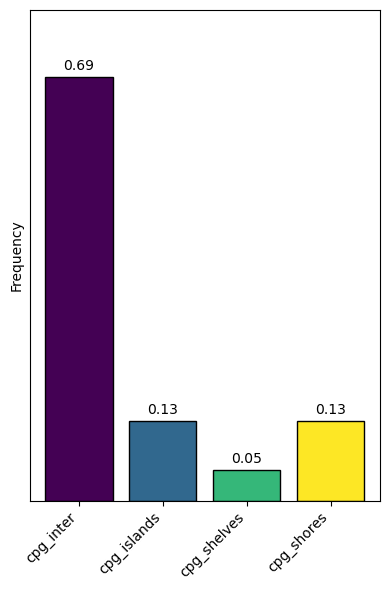

In [94]:
category_counts_cpg= category_counts[['cpg_inter', 'cpg_islands', 'cpg_shelves', 'cpg_shores']]

# Create the bar plot
fig, ax = plt.subplots(figsize=(4, 6))  # You can adjust figsize as needed
types = category_counts_cpg.index
colors = plt.cm.get_cmap('viridis', len(types))
# Create bars with colors from the colormap
bars = ax.bar(category_counts_cpg.index, category_counts_cpg.values, 
              color=colors(range(len(types))), edgecolor='black', linewidth=1)
# Rotate the category labels by 45 degrees
plt.xticks(rotation=45, ha='right')  # ha='right' ensures better alignment for rotated text
# Add counts above each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate('{}'.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

# Set labels and ticks
ax.set_ylabel('Frequency')
ax.set_yticks([])  # Removes the y-axis ticks
ax.set_ylim(0, 0.8)
# Adjust layout to prevent the x-axis labels from being cut off
plt.tight_layout()
# Save the figure as a PDF with dpi=300
plt.savefig("barplot_mpra_annotatr_cpg.pdf", format='pdf', dpi=300)
plt.show()
